In [1]:
%load_ext autoreload
%autoreload 2

import json
from os.path import join
import copy
import random
import numpy as np
import pandas as pd 
from scipy import stats
from tqdm import tqdm
import math

import torch
import torch.nn.functional as F

from common.config import JsonConfig
from ffm_iql.builder import build 
from ffm_iql.evaluation import evaluate, sample_scanpaths


from PIL import ImageFont, Image, ImageDraw
font = ImageFont.truetype("Gidole-Regular.ttf", size=32)
import cv2

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns


from visualization_utils import *
import datetime as dt
today = dt.date.today()          # e.g. datetime.date(2025, 7, 15)
today_mmdd = today.strftime("%m%d")  # '0715'

device = torch.device('cuda:1')
# device = torch.device('cpu')
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [2]:
CATEGORIES18 = ['bottle',
'bowl',
'car',
'chair',
'clock',
'cup',
'fork',
'keyboard',
'knife',
'laptop',
'microwave',
'mouse',
'oven',
'potted plant',
'sink',
'stop sign',
'toilet',
'tv']

# load model and dataset

In [3]:
TAP='TP' 
# TAP='TPtoTA'

#dataset_root = '/home/young/hdd1/coco-search18/'
dataset_root = '/data/datasets/coco-search18-IRL/'
hparams = JsonConfig('./configs/coco_search18_eDCB_IQL_TP_LIOR.json')
# hparams = JsonConfig('./configs/coco_search18_eDCB_IQL_TA_LIOR.json')


# hparams.Train['force_IOR'] = False

# save_visualization = False
# log_dir = './results/explore_it'
# if not os.path.exists(log_dir):
#     os.makedirs(log_dir)
# print("Log dir:", log_dir)
# config_dir = os.path.dirname(args.hparams)

hparams_tp = JsonConfig('./configs/coco_search18_TP.json')
hparams_ta = JsonConfig('./configs/coco_search18_TA.json')
hparams_fv = JsonConfig('./configs/coco_search18_FV.json')

if TAP=='TPtoTA':
    # change hparam to TA setup
    hparams_ta_training = JsonConfig('./configs/coco_search18_eDCB_IQL_TA_LIOR.json')
    maxtrajcopy = hparams.Data.max_traj_length
    hparams.Data = hparams_ta_training.Data
    hparams.Data.max_traj_length =maxtrajcopy
    hparams_ta.Data.max_traj_length =maxtrajcopy
    

# build model
agent, train_gaze_loader, train_img_loader, valid_img_loader,\
    valid_img_loader_ta, valid_img_loader_fv, env, env_valid, global_step, bbox_annos,\
    human_cdf, fix_clusters, prior_maps_tp, prior_maps_ta, prior_maps_fv,\
    sss_strings, valid_gaze_loader_tp, valid_gaze_loader_ta, valid_gaze_loader_fv,\
    sps_test_tp, sps_test_ta, sps_test_fv = build(
        hparams, dataset_root, device, load_coco_annos=False)



# using DCB dataset: COCO-Search18 TAP: TP
# average train scanpath length : 3.637 (+/-1.850)
# num of train trajs = 18961
# average valid scanpath length : 3.620 (+/-1.782)
# num of valid trajs = 5424
# target fixation prob (valid).: [0.00847614 0.46334244 0.80982789 0.93608998 0.97351685 0.9874683 ]
# num of training and eval fixations = 35856, 9974
# num of training and eval images = 2163, 612 (TP), 612 (TA), 0(FV)
# num of training batches = 1120
# loaded weights from ./pretrained/ckp_temporal_TP.pt.


# using DCB dataset: COCO-Search18 TAP: TA
# average train scanpath length : 5.836 (+/-4.035)
# num of train trajs = 21627
# average valid scanpath length : 5.852 (+/-4.208)
# num of valid trajs = 6120
# target fixation prob (valid).: [0.00847614 0.46334244 0.80982789 0.93608998 0.97351685 0.9874683
#  0.99304122]
# num of training and eval fixations = 104597, 29694
# num of training and eval images = 2163, 612 (TP), 612 (TA), 0(FV)
# num of training batches = 3268
# loaded weights from ./pretrained/ckp_temporal_TP.pt.

# load baselines
DETECTOR_PRED_PATH = f"./baselines/Foveated Detector/pred_{TAP}_detection_hilow_aug_noIOR_truncated.npy"
HAT_PRED_PATH = f"./baselines/HAT/pred_{TAP}_HAT.npy"
print('baseline loaded')

using DCB dataset: COCO-Search18 TAP: TP
average train scanpath length : 3.637 (+/-1.850)
num of train trajs = 18961
average valid scanpath length : 3.620 (+/-1.782)
num of valid trajs = 5424
target fixation prob (valid).: [0.00847614 0.46334244 0.80982789 0.93608998 0.97351685 0.9874683 ]
num of training and eval fixations = 35856, 9974
num of training and eval images = 2163, 612 (TP), 612 (TA), 0(FV)
num of training batches = 1120
loaded weights from ./pretrained/ckp_temporal_TP.pt.
baseline loaded


## Generate model scanpaths and reward maps 

In [4]:
# code modified from evalaute in evaluation.py
env = env_valid
model = agent

if hparams.Data.TAP == 'TP':
    dataloader = valid_img_loader # train_img_loader for using training image
    pa= hparams_tp.Data
#     pa['enforce_IOR'] = False
#     print(pa)
if hparams.Data.TAP == 'TA':
    dataloader =  valid_img_loader_ta
    pa= hparams_ta.Data
#     pa['enforce_IOR'] = False

model.eval()


scanpaths, visualizations = sample_scanpaths(env, model, dataloader, pa,
                                             sample_action=False, 
                                             sample_scheme='Greedy', # this is not necessary
                                             sample_stop=False,
                                             save_visualization=True)

Generating scanapths...


  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:36<00:00,  1.84s/it]


# Test model performance

In [ ]:
# # code modified from evalaute in evaluation.py
# # insert log_dir for saving visualizations

# env = env_valid
# model = agent

# def run_evaluation():
#     rst_tp, rst_ta, rst_fv = None, None, None
#     if hparams.Data.TAP in ['TP', 'TAP']:
#         rst_tp = evaluate(
#             env_valid,
#             agent,
#             valid_img_loader,
#             valid_gaze_loader_tp,
#             hparams_tp.Data,
#             bbox_annos,
#             human_cdf,
#             fix_clusters,
#             prior_maps_tp,
#             sss_strings,
#             dataset_root,
#             sps_test_tp,
#             sample_action=False,
#             sample_scheme='Greedy',
#             log_dir=None,
#             save_visualization=False,
#         )
#         print("TP:", rst_tp)
#     if hparams.Data.TAP in ['TA', 'TAP']:
#         rst_ta = evaluate(
#             env_valid,
#             agent,
#             valid_img_loader_ta,
#             valid_gaze_loader_ta,
#             hparams_ta.Data,
#             bbox_annos,
#             human_cdf,
#             fix_clusters,
#             prior_maps_ta,
#             sss_strings,
#             dataset_root,
#             sps_test_ta,
#             sample_action=False,
#             sample_scheme='Greedy',
#             log_dir=None,
#             save_visualization=False,
#         )
#         print("TA", rst_ta)
#     if hparams.Data.TAP in ['FV', 'ALL']:
#         rst_fv = evaluate(
#             env_valid,
#             agent,
#             valid_img_loader_fv,
#             valid_gaze_loader_fv,
#             hparams_fv.Data,
#             bbox_annos,
#             human_cdf,
#             fix_clusters,
#             prior_maps_fv,
#             sss_strings,
#             dataset_root,
#             sps_test_fv,
#             sample_action=False,
#             sample_scheme='Greedy',
#             log_dir=None,
#             save_visualization=False,
#         )
#         print("FV", rst_fv)
#     return rst_tp, rst_ta, rst_fv

# metrics = run_evaluation()
# # print(metrics)]

# # generate categoriwise performance
# metric_columns = ['TFP', 'SS', 'SemSS', 'cIG', 'cNSS', 'cAUC', 'SPR']
# # metric_columns = ['SemSS', 'SS', 'cIG', 'cNSS', 'cAUC']

# dfs = []
# for i, cat in enumerate(CATEGORIES18:
#     df = pd.read_csv(f'results/DCBablation_SemSSupdated/metric_{cat}.csv')
#     dfs.append(df.iloc[0].to_frame().transpose().copy())
    
# alldf = pd.concat(dfs)[metric_columns]
# alldf['label'] = CATEGORIES18
# alldf.to_csv('results/TP_all_categories_SemSSupdated.csv', index=False)
# alldf

# Load human scanpaths

In [5]:
def load_human_scanpaths(split, TAP, dataset_root='/data/datasets/coco-search18-IRL/'):
    print(f'Generating {split} dataset for: {TAP}')
    fixation_path = dataset_root + 'coco_search_fixations_512x320_on_target_allvalid.json'
    with open(fixation_path) as json_file:
        human_all = json.load(json_file)

    if TAP == 'TP':
        human = list(filter(lambda x: x['condition'] == 'present' and x['split'] == split, human_all))
    else:
        human = list(filter(lambda x: x['condition'] == 'absent' and x['split'] == split, human_all))

    for sp in human:
        sp['X'][0], sp['Y'][0] = 256, 160  # center correction

    print(f'Total scanpaths for {split}:', len(human))
    return human


human_scanpaths = load_human_scanpaths('test', TAP, dataset_root)
taskimgpair = np.unique([sp['task'] + "_" + sp['name'] for sp in human_scanpaths])
print('unique task-img pair', len(taskimgpair))


######
# image-wise stats
#####
statperimage = pd.DataFrame()

tasks, imgnames, nfixs, nfixs_sd, accs, accs_sd= [], [], [], [], [], []
for pair in taskimgpair:
    task= pair.split('_')[0]
    imgname = pair.split('_')[1]
    tasks.append(task)
    imgnames.append(imgname)
    
    img_scanpaths = list(filter(lambda x: x['task'] +"_"+ x['name'] == pair, human_scanpaths))

    if TAP=='TP':
        valid_sp = list(filter(lambda x: x['correct'] and x['fixOnTarget'], img_scanpaths))

        acc = len(valid_sp)/(len(img_scanpaths))
        accs.append(acc)

        nfix = [sp['length'] for sp in valid_sp]
        nfixs.append(np.mean(nfix) if nfix else np.nan)
        # nfixs_sd.append(np.std(nfix))
    
    elif TAP=='TPtoTA':
        accs.append(np.nan)
        nfix = [sp['length'] for sp in img_scanpaths]
        nfixs.append(np.mean(nfix) if nfix else np.nan)
        # nfixs_sd.append(np.std(nfix))

statperimage['category']= tasks
statperimage['imgname']= imgnames
statperimage['nfix']= nfixs
# statperimage['nfix_sd']= nfixs_sd
statperimage['acc']= accs

######
# statistics per category
#####
# nfix is num of fixations made til button press
gazestat=pd.DataFrame()
nfixs, fixs_sd, accs = [], [], []
for category in CATEGORIES18:
    if TAP=='TP':
        valid_task_sp = list(filter(lambda x: x['task'] == category and x['correct'] and x['fixOnTarget'], human_scanpaths))
        invalid_task_sp = list(filter(lambda x: x['task'] == category and not (x['correct'] and x['fixOnTarget']), human_scanpaths))

        acc = len(valid_task_sp)/(len(valid_task_sp)+len(invalid_task_sp))
        accs.append(acc)
    
        nfix = [sp['length'] for sp in valid_task_sp]
        nfixs.append(np.mean(nfix) if nfix else np.nan)
        nfixs_sd.append(np.std(nfix) if nfix else np.nan)
    elif TAP=='TPtoTA':
        valid_task_sp = list(filter(lambda x: x['task'] == category and x['correct'], human_scanpaths))
        
        accs.append(np.nan)
        
        nfix = [sp['length'] for sp in valid_task_sp]
        nfixs.append(np.mean(nfix) if nfix else np.nan)
        nfixs_sd.append(np.std(nfix) if nfix else np.nan)
    
gazestat['category'] = CATEGORIES18
gazestat['acc'] = accs
gazestat['nfix'] = nfixs
gazestat['nfix_sd'] = nfixs_sd
display(gazestat)


Generating test dataset for: TP
Total scanpaths for test: 6118
unique task-img pair 612


,category,acc,nfix,nfix_sd
0,bottle,0.878788,4.451724,1.866053
1,bowl,0.764286,4.247664,1.945368
2,car,0.825000,3.866667,1.995551
3,chair,0.808000,3.688119,1.611148
4,clock,0.969565,2.802691,0.767380
5,cup,0.847273,3.729614,1.488101
6,fork,0.839130,3.287565,1.687412
7,keyboard,0.852778,2.866450,0.961006
8,knife,0.878571,3.865854,1.186943
9,laptop,0.920833,3.547511,1.363306


# reward map visualizations
- temporal evolution of groundtruth needed...

In [ ]:
# #qvalue map 
# import matplotlib.pyplot as plt
# step=0
# plt.hist(visualizations[0][2][step])

In [13]:
category = 'microwave'
# category = 'bottle'
category = 'bowl'
# category = 'potted plant'
# category = 'stop sign'
# category = 'cup'
# category = 'mouse'
# category = 'fork'
# category = 'knife'
# category = 'tv'
# category = 'clock'
# category = 'chair'
# category = 'car'
# def filter_by_category(x, catname):
#     return x[0] == catname
# vis = list(filter(lambda x: filter_by_category(x, category), visualizations))

# filter visualizations and scanpaths by category
vis_category = []
scanpath_category = []
for i, vis in enumerate(visualizations):
    if vis[0] == category:
        vis_category.append(vis)
        scanpath_category.append(scanpaths[i])
print(f'# of visualization data for {category}: ', len(vis_category))


# sample N easy and hard images
N_SAMPLE = 10
sorteddf = statperimage[statperimage.category==category].sort_values(by='nfix')
easy_images = sorteddf['imgname'].tolist()[:N_SAMPLE]
easy_nfixs = sorteddf['nfix'].tolist()[:N_SAMPLE]
hard_images = sorteddf['imgname'].tolist()[-abs(N_SAMPLE):]
hard_nfixs = sorteddf['nfix'].tolist()[-abs(N_SAMPLE):]
print(f'{N_SAMPLE} easy and hard images sampled')



# of visualization data for bowl:  28
10 easy and hard images sampled


Loaded baseline 'detector' from ./baselines/Foveated Detector/pred_TP_detection_hilow_aug_noIOR_truncated.npy with 612 items
Loaded baseline 'hat' from ./baselines/HAT/pred_TP_HAT.npy with 612 items
Rendering 000000209145.jpg
Saved to ./results/savefig/TP_attention_map_bowl_000000209145.jpg.png


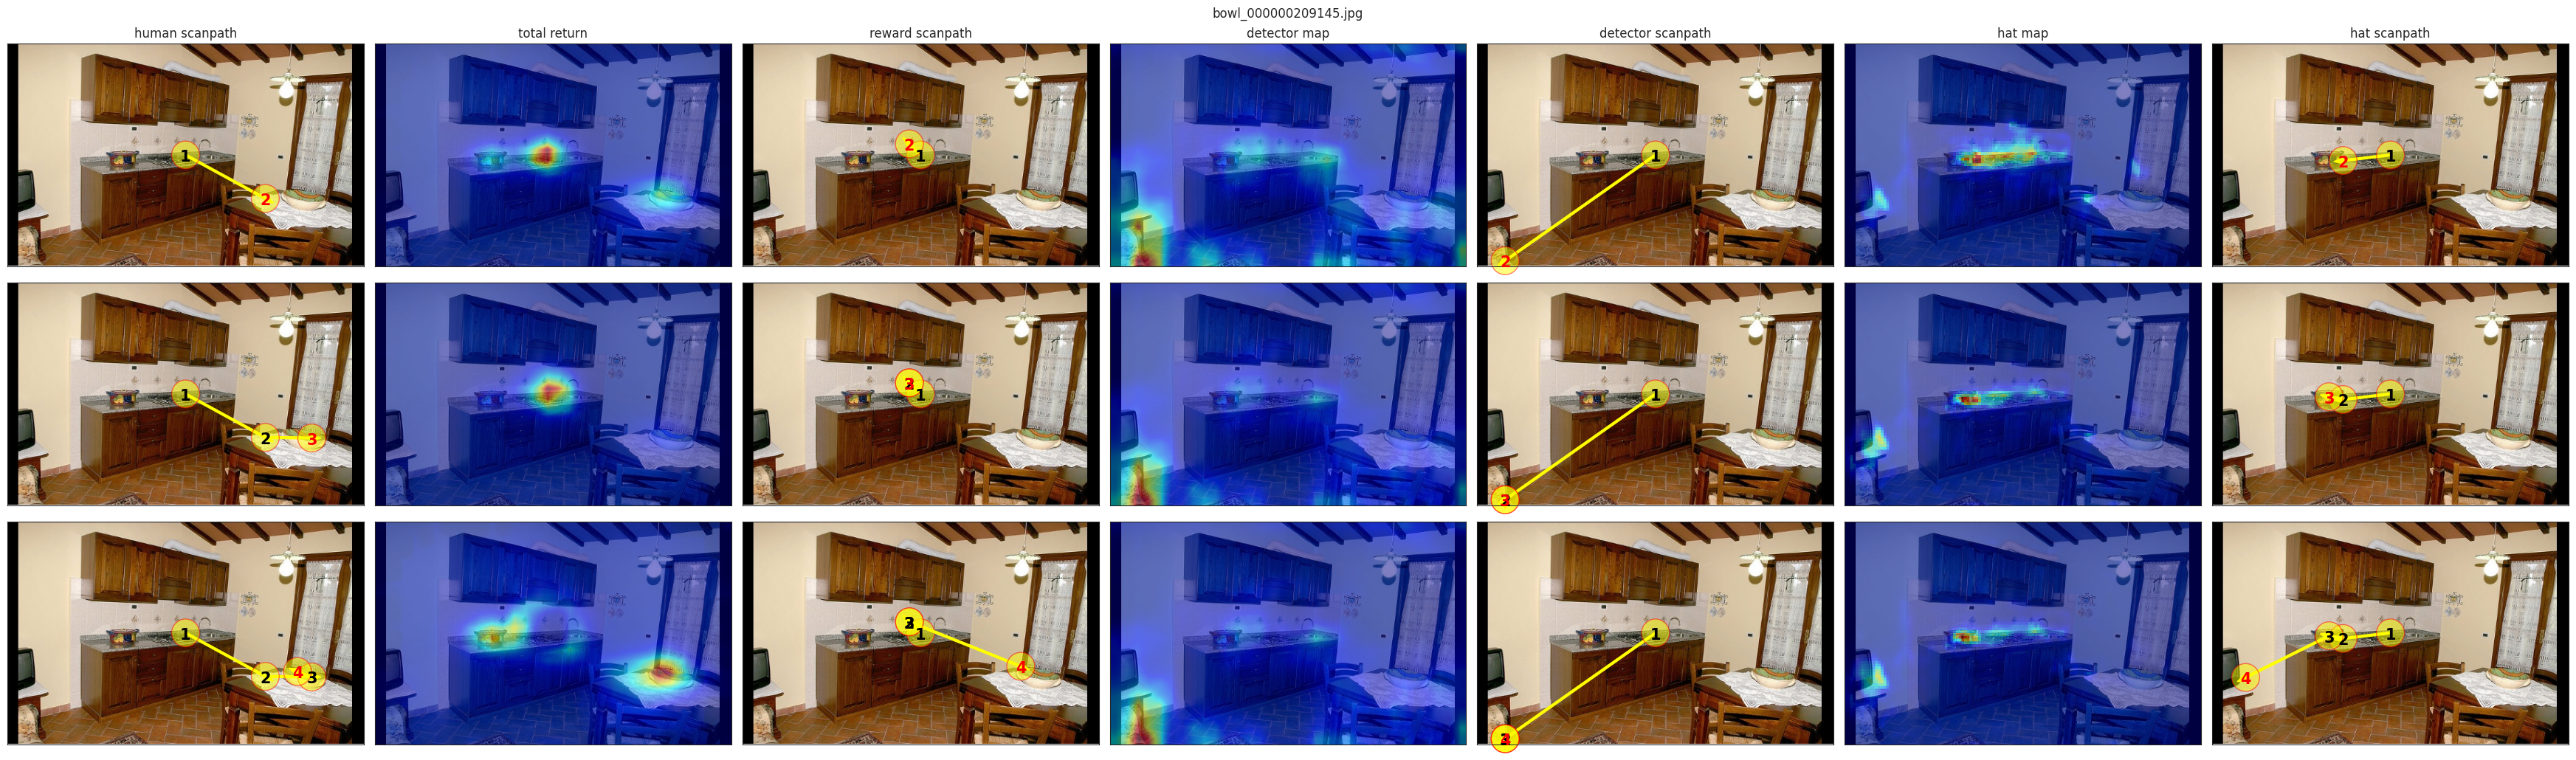

In [15]:
# visualize attention maps and scanpaths
## TODO: for TA condition you still get 6 for visualizations not entire
# 48939 training image is used for figure
# 000000253489.jpg for bottle change

# imglist_to_save = None
# # imglist_to_save=['000000253489.jpg'] # bottle search, explore-exploit change
# # imglist_to_save = ['000000325992.jpg'] # bottle
# # imglist_to_save =['000000360849.jpg'] # toilet search, easy case for entropy # 3 steps on average
# # imglist_to_save = ['000000124707.jpg'] # microwave search, hard case for entropy # 10 steps on average
# # imglist_to_save = ['000000317565.jpg', '000000345536.jpg', '000000415949.jpg'] # potted plant search TP (difficult case, for IOR illusrations)
# # imglist_to_save = ['000000317565.jpg'] # potted plant search TP (difficult case, for IOR illusrations)
# # imglist_to_save = ['000000096183.jpg' ] # microwave

# imglist_to_visualize = hard_images
# # imglist_to_visualize = imglist_to_save
# # imglist_to_visualize = 'all'
# imglist_to_visualize = ['000000296388.jpg']

# repscanpath = selected_human_scanpaths[2] # subj 5 >0 for microwave; subj 2>8 for potted plant



cfg = VizConfig(
    maps_to_visualize=[
        "human scanpath",
        # "human fdm",
        # "immediate reward",
        # "expected future reward",
        "total return",
        # "action prob",
        "reward scanpath",
        "baseline attention map",   # this will now add *one column per baseline*
        "baseline scanpath",        # likewise, one column per baseline
    ],
    tap=TAP,  
    # imglist_to_visualize= ['000000096183.jpg'], # microwave TP
    # imglist_to_save = ['000000096183.jpg'],
    imglist_to_visualize= ['000000209145.jpg'], # bowl TP
    imglist_to_save = ['000000209145.jpg'],
    # imglist_to_visualize= ['000000317565.jpg'], # potted plant TP
    # imglist_to_save = ['000000317565.jpg'],
    # imglist_to_visualize= ['000000231822.jpg'], # bottle TP
    # imglist_to_save = ['000000231822.jpg'],
    # imglist_to_visualize= hard_images,
    # imglist_to_save=[],
    save_path=f"./results/savefig/{TAP}_attention_map_",  # where to save the figures
    plot_entropy=False,
    baselines=[
        BaselineSpec(
            name="detector",
            pred_path= DETECTOR_PRED_PATH,
        ),
        BaselineSpec(
            name="hat",
            pred_path= HAT_PRED_PATH 
        )
    ],
)

visualize_rewardmaps(
    vis_category=vis_category,
    scanpath_category=scanpath_category,
    human_scanpaths=human_scanpaths,
    dataset_root=dataset_root,
    hparams=hparams,
    cfg=cfg,
)



# reward depletion
- at reward t: get 24 radius region of fixated; st = compute sum of values
- at reward t+1: get 24 radius region of previously fixated (same region); st+1 = compute sum of values
- (st - st+1) --> current - future reward. if positive :depleted, if zero or negative: not depleted

baseline "detector" loaded from ./baselines/Foveated Detector/pred_TP_detection_hilow_aug_noIOR_truncated.npy
baseline "hat" loaded from ./baselines/HAT/pred_TP_HAT.npy


Processing categories: 100%|██████████| 18/18 [00:01<00:00, 12.81it/s]


[saved] ./results/savefig/TP_reward_depletion_overall_multi_fixonly.png


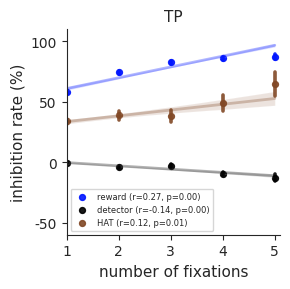

In [8]:
# ────────────────────────────────────────────────────────────────
# Multi-baseline reward depletion analysis (supports "target" + "hat")
# ────────────────────────────────────────────────────────────────
# Assumes the following exist in your workspace:
# - CATEGORIES18, visualizations, scanpaths
# - compute_reward(map, mask), foveal2mask(x, y, r, h, w)
# - format_p(p)   # pretty p-value formatter
# Uses: scipy.stats as stats, pandas as pd, numpy as np, tqdm

# === CONFIG ===
BASELINES = [
    # name, path pattern
    ("detector", DETECTOR_PRED_PATH),
    ("hat",    HAT_PRED_PATH),        
]
USE_DELTA = False
CURR_FIX_ONLY = True # if false, we are computing entire scene
RADIUS = 24

if CURR_FIX_ONLY:
    depletion_area = 'fixonly'
    ylabel = 'inhibition rate (%)'
else:
    depletion_area = 'entirescene'
    ylabel = 'priority depletion (%)'

SAVE_PATH = f'./results/savefig/{TAP}_reward_depletion_overall_multi_{depletion_area}.png'



# === LOAD BASELINES (optional if files missing) ===
baseline_preds = {}
for name, path in BASELINES:
    try:
        baseline_preds[name] = np.load(path, allow_pickle=True)
        print(f'baseline "{name}" loaded from {path}')
    except Exception as e:
        print(f'[WARN] Could not load baseline "{name}" from {path}: {e}')


# ───────────────────────────────────────────────────────
# Helper: compute rows for one model sequence (maps + fixations)
# ───────────────────────────────────────────────────────

def _minmax_norm(arr):
    arr = arr.astype(np.float32)
    a_min = np.nanmin(arr)
    a_max = np.nanmax(arr)
    rng = a_max - a_min
    if rng <= 1e-12:
        return np.zeros_like(arr, dtype=np.float32)
    return (arr - a_min) / rng

def _softmax_norm(arr, tau=1.0):
    # Produces a probability map that sums to 1 (over the whole image)
    # Lower tau -> sharper distribution; tau must be >0
    arr = arr.astype(np.float32)
    tau = float(tau) if tau is not None else 1.0
    if tau <= 0:
        tau = 1.0
    a = arr / tau
    a = a - np.nanmax(a)  # stabilize
    expa = np.exp(a)
    s = expa.sum()
    if s <= 1e-12:
        # fallback: uniform map if everything underflowed
        h, w = arr.shape
        return np.full((h, w), 1.0 / (h * w), dtype=np.float32)
    return expa / s

def compute_rows_one_model(model_name,
                           maps_seq,           # list/array of 2D maps for this model
                           fix_x_seq=None,     # list of X fixations for this model (optional)
                           fix_y_seq=None,     # list of Y fixations for this model (optional)
                           map_index_offset=0, # 0 for ours, 1 for baseline to mimic attn_map[step+1]
                           curr_fix_only=False,
                           radius=24,
                           h=None, w=None,
                           category=None, image_name=None,
                           use_delta=False,
                           norm='none',        # 'none' | 'minmax' | 'softmax'
                           softmax_temp=1.0):
    out = {'model': [], 'category': [], 'imgname': [], 'step': [], 'backN': [], 'IOR': [], 'curr_reward':[], 'next_reward':[]}

    n_eff = len(maps_seq) - map_index_offset
    if n_eff <= 1:
        return out  # nothing to compute

    # choose normalizer
    if norm == 'minmax':
        _norm_fn = _minmax_norm
    elif norm == 'softmax':
        _norm_fn = lambda a: _softmax_norm(a, tau=softmax_temp)
    else:
        _norm_fn = lambda a: a  # no-op

    for step in range(n_eff - 1):
        i_curr = step + map_index_offset

        # Build fixation mask at t = step+1 (to mirror your original convention)
        if curr_fix_only and (fix_x_seq is not None) and (fix_y_seq is not None):
            if step + 1 >= len(fix_x_seq) or step + 1 >= len(fix_y_seq):
                continue  # no fixation for this step; skip
            fx, fy = fix_x_seq[step + 1], fix_y_seq[step + 1]
            fix_mask = foveal2mask(fx, fy, radius, h, w)
        else:
            fix_mask = np.ones((h, w), dtype=np.uint8)

        # Normalize current map
        curr_map = _norm_fn(maps_seq[i_curr])
        curr_reward = compute_reward(curr_map, fix_mask)


        for next_step in range(step + 1, n_eff):
            i_next = next_step + map_index_offset

            # Normalize next map
            next_map = _norm_fn(maps_seq[i_next])
            next_reward = compute_reward(next_map, fix_mask)

            if use_delta:
                # delta computed on normalized maps
                delta_map = np.clip(curr_map - next_map, 0, None)
                denom = (curr_map[fix_mask].sum() + 1e-5)
                IOR_val = 1 - (delta_map[fix_mask].sum() / denom)
                # IOR_val = 1 - (delta_map[fix_mask].sum() / denom)

            else:
                # depletion ratio using normalized rewards
                # IOR_val = 1 - np.clip((curr_reward - next_reward) / (curr_reward + 1e-5), 0, 1)
                IOR_val = (curr_reward - next_reward) / (curr_reward + 1e-5)

            out['model'].append(model_name)
            out['category'].append(category)
            out['imgname'].append(image_name)
            out['step'].append(step + 1)           # 1-based
            out['backN'].append(next_step - step)  # distance
            out['IOR'].append(IOR_val)
            out['curr_reward'].append(curr_reward)
            out['next_reward'].append(next_reward)

    return out
# ───────────────────────────────────────────────────────
# MAIN LOOP — independent per model lengths
# ───────────────────────────────────────────────────────
rows = { 'model': [], 'category': [], 'imgname': [], 'step': [], 'backN': [], 'IOR': [] , 'curr_reward':[], 'next_reward':[]}

for category in tqdm(CATEGORIES18, desc="Processing categories"):
    vis_category = [vis for vis in visualizations if vis[0] == category]
    scanpath_category = [scanpaths[i] for i, vis in enumerate(visualizations) if vis[0] == category]
    if not vis_category:
        continue

    for vis, sp in zip(vis_category, scanpath_category):

        image_name, maps_ours = vis[1], vis[2] # total return
        h, w = maps_ours[0].shape

        if len(maps_ours) <= 1:
            pass
        else:
            ours_dict = compute_rows_one_model(
                model_name='ours',
                maps_seq=maps_ours,
                fix_x_seq=sp.get('X') if CURR_FIX_ONLY else None,
                fix_y_seq=sp.get('Y') if CURR_FIX_ONLY else None,
                map_index_offset=0,
                curr_fix_only=CURR_FIX_ONLY,
                radius=RADIUS,
                h=h, w=w,
                category=category, image_name=image_name,
                use_delta=USE_DELTA
            )
            for k in rows: rows[k].extend(ours_dict[k])

        # 2) Each baseline — compute independently with each baseline’s own length & fixations
        for bname, bpred_list in baseline_preds.items():
            matches = [item for item in bpred_list
                       if item['name'] == image_name and item['task'] == category]
            if not matches:
                continue
            bpred = matches[0]

            # Need attn_map and matching HxW
            attn_seq = bpred.get('attn_map', None)
            if not attn_seq or len(attn_seq) == 0:
                continue
            if attn_seq[0].shape != (h, w):
                continue

            # If you want baseline masks to follow our fixations, swap to sp['X']/['Y'] here.
            fix_x_b = bpred.get('X') if CURR_FIX_ONLY else None
            fix_y_b = bpred.get('Y') if CURR_FIX_ONLY else None

            # Offsets per model: target=1 (it starts with center bias, first is always center, predict cetner), hat=0 (first attnmap predict second fix)
            offset_by_model = {'detector': 1, 'hat': 0}
            b_offset = offset_by_model.get(bname, 0)

            b_dict = compute_rows_one_model(
                model_name=bname,
                maps_seq=attn_seq,
                fix_x_seq=fix_x_b,
                fix_y_seq=fix_y_b,
                map_index_offset=b_offset,  # keep your original attn_map[step+1] convention
                curr_fix_only=CURR_FIX_ONLY,
                radius=RADIUS,
                h=h, w=w,
                category=category, image_name=image_name,
                use_delta=USE_DELTA
            )

            for k in rows: rows[k].extend(b_dict[k])

idf = pd.DataFrame(rows)

# Collect per-model stats
stats_dict = {}
for model_name, g in idf.groupby('model'):
    if len(g) >= 2:
        slope, intercept, corr, pvalue, _ = stats.linregress(g['backN'], g['IOR'])
        stats_dict[model_name] = (corr, pvalue)
    else:
        stats_dict[model_name] = (None, None)

# Plot with stats in legend
plot_joint_multi(
    idf,
    SAVE_PATH,
    use_legend=True,
    legend_loc='lower left',
    title=f'{TAP}',
    ylabel=ylabel,
    ytickslist=[-0.5, 0, 0.5, 1],
    stats_dict=stats_dict,
    show_plot=True
)

In [10]:
# ───────────────────────────────────────────────────────────────
# Per-category stats + plots
# ───────────────────────────────────────────────────────────────
from pathlib import Path
from visualization_utils import _safe_linregress

outdir = Path('./results/savefig')
outdir.mkdir(parents=True, exist_ok=True)
save_plot = False

# Build a fast lookup: category -> nfix
nfix_lookup = (
    gazestat
    .set_index('category')['nfix']
    .to_dict()
)

print('\nPer-category fixation step × reward depletion correlation:')
cat_rows = {'category': [], 'model': [], 'slope': [], 'intercept': [], 'r': [], 'p': []}

for cat, gcat in idf.groupby('category'):
    print(f'\n== Category: {cat} ==')

    # pull nfix for this category (rounded to 2 decimals)
    nfix_val = nfix_lookup.get(cat, np.nan)
    if pd.notna(nfix_val):
        nfix_text = f"{nfix_val:.2f}"
    else:
        nfix_text = "NA"  # fallback if not found

    # collect stats for this category
    stats_dict = {}

    for model_name, g in gcat.groupby('model'):
        slope, intercept, r, p = _safe_linregress(g['backN'].values, g['IOR'].values)
        cat_rows['category'].append(cat)
        cat_rows['model'].append(model_name)
        cat_rows['slope'].append(slope)
        cat_rows['intercept'].append(intercept)
        cat_rows['r'].append(r)
        cat_rows['p'].append(p)

        if np.isnan(r):
            print(f'  {model_name:>7s} : not enough/degenerate data')
            stats_dict[model_name] = (None, None)
        else:
            print(f'  {model_name:>7s} : r = {round(r,3)}, p = {round(p,3)}')
            stats_dict[model_name] = (r, p)

    # Per-category plot with nfix in the title (2 decimals)
    if save_plot:
        subdf = idf[idf['category'] == cat].copy()
        save_path_cat = outdir / f'{TAP}_{cat}_reward_depletion_multi_{depletion_area}.png'
        plot_joint_multi(
            subdf,
            str(save_path_cat),
            use_legend=True,
            title=f'{cat} ({nfix_text})',  
            stats_dict=stats_dict,
            show_plot=False
        )

# Optional: save a tidy CSV of per-category stats 
cat_stats_df = pd.DataFrame(cat_rows) 
cat_stats_csv = outdir / f'{TAP}_reward_depletion_per_category_stats_{depletion_area}.csv' 
cat_stats_df.to_csv(cat_stats_csv, index=False)
print(f'\n[INFO] Per-category figures saved to: {outdir}') 
print(f'[INFO] Per-category stats saved to: {cat_stats_csv}')


Per-category fixation step × reward depletion correlation:

== Category: bottle ==
  detector : r = -0.15, p = 0.093
      hat : r = 0.363, p = 0.009
     ours : r = 0.154, p = 0.197

== Category: bowl ==
  detector : r = -0.162, p = 0.03
      hat : r = 0.39, p = 0.001
     ours : r = 0.295, p = 0.0

== Category: car ==
  detector : r = -0.234, p = 0.005
      hat : r = 0.285, p = 0.12
     ours : r = 0.169, p = 0.095

== Category: chair ==
  detector : r = -0.165, p = 0.003
      hat : r = 0.096, p = 0.389
     ours : r = 0.333, p = 0.0

== Category: clock ==
  detector : r = -0.171, p = 0.341
      hat : not enough/degenerate data
     ours : r = 0.502, p = 0.048

== Category: cup ==
  detector : r = -0.094, p = 0.087
      hat : r = 0.236, p = 0.098
     ours : r = 0.295, p = 0.0

== Category: fork ==
  detector : r = -0.104, p = 0.107
      hat : r = -0.146, p = 0.277
     ours : r = 0.388, p = 0.0

== Category: keyboard ==
  detector : r = -0.001, p = 0.994
      hat : r = 0.419

In [14]:
# collage plot
# If you want the default alphabetical category order:
plot_all_categories_grid(idf, gazestat,
    save_path=f"./results/savefig/{TAP}_reward_depletion_GRID_4x5_{depletion_area}.png",
    ncols=5,
    nrows=4,
    ylabel=ylabel,
    ytickslist=[-0.5, 0, 0.5, 1.0],
    legend_loc= 'lower left',
    )

# Build list of categories sorted by nfix
cats_sorted = (
    gazestat[['category', 'nfix']]
    .dropna(subset=['nfix'])
    .sort_values('nfix', ascending=True)['category']
    .tolist()
)

# Then call the collage plot with this order
plot_all_categories_grid(
    idf, gazestat,
    categories=cats_sorted[:3]+cats_sorted[-3:],
    save_path=f"./results/savefig/{TAP}_reward_depletion_GRID_selected_{depletion_area}.png",
    ncols=3,
    nrows=2,
    ylabel=ylabel,
    ytickslist=[-0.5, 0, 0.5, 1.0],
    legend_loc= 'lower left',
)

[saved] ./results/savefig/TP_reward_depletion_GRID_4x5_fixonly.png
[saved] ./results/savefig/TP_reward_depletion_GRID_selected_fixonly.png


In [12]:
behavior_measure = "nfix"  
results_corr = []

def safe_corr(x, y):
    """Compute Pearson r, p-value ignoring NaNs. Returns (r, p) or (nan, nan)."""
    mask = ~np.isnan(x) & ~np.isnan(y)
    if mask.sum() < 2:
        return np.nan, np.nan
    return stats.pearsonr(x[mask], y[mask])

for model_name, g in cat_stats_df.groupby('model'):
    merged = g.merge(
        gazestat[['category', behavior_measure]],
        on='category',
        how='inner'
    )

    # Compute correlations
    if len(merged) >= 2:
        slope_r, slope_p = safe_corr(merged['slope'], merged[behavior_measure ])
        intercept_r, intercept_p = safe_corr(merged['intercept'], merged[behavior_measure])
    else:
        slope_r = slope_p = intercept_r = intercept_p = np.nan

    results_corr.append({
        'model': model_name,
        'slope_r': slope_r, 'slope_p': slope_p,
        'intercept_r': intercept_r, 'intercept_p': intercept_p,
        'n_cats': len(merged)
    })

corr_df = pd.DataFrame(results_corr)

print("\nCorrelation between regression coefficients and human data:")
print(corr_df)


corr_df.to_csv(f"./results/savefig/{TAP}_corrdf_{depletion_area}.csv")


Correlation between regression coefficients and human data:
      model   slope_r   slope_p  intercept_r  intercept_p  n_cats
0  detector -0.392869  0.106795     0.019174     0.939805      18
1       hat -0.037231  0.895197    -0.173065     0.537360      18
2      ours -0.542260  0.020079     0.355034     0.148250      18


In [ ]:
# # summary statistics
# grand = (
#     idf
#     .groupby('backN')['IOR']                          # group by the N‑back distance
#     .agg(mean='mean', std='std', count='count')       # calculate all stats at once
#     .assign(se=lambda x: x['std'] / np.sqrt(x['count']))
# )
# print("\n=== GRAND MEAN (all categories) ===")
# print(grand.round(3))


# cat_summary = (
#     idf
#     .groupby(['category', 'backN'])['IOR']
#     .agg(mean='mean', std='std', count='count')
#     .assign(se=lambda x: x['std'] / np.sqrt(x['count']))
#     .reset_index()
# )

# # print("\n=== BY CATEGORY (first few rows) ===")
# # print(cat_summary.head().round(3))

# # If you’d rather see a matrix of means with back‑N on rows and category on columns:
# mean_matrix = cat_summary.pivot(index='backN', columns='category', values='mean')
# print("\n=== MATRIX OF MEANS ===")
# print(mean_matrix.round(3))


# step_summary = (
#     idf
#     .groupby(['step', 'backN'])['IOR']
#     .agg(mean='mean', std='std', count='count')
#     .assign(se=lambda x: x['std'] / np.sqrt(x['count']))
#     .reset_index()
# )

# # print("\n=== BY FIXATION STEP (first few rows) ===")
# # print(step_summary.head().round(3))

# mean_mat = step_summary.pivot(index='backN', columns='step', values='mean').round(3)
# se_mat   = step_summary.pivot(index='backN', columns='step', values='se').round(3)

# print("\n=== MEAN IOR (rows = N‑back, cols = fixation step) ===")
# print(mean_mat)
# # print("\n=== STANDARD ERROR ===")
# # print(se_mat)

